# 02. Modelado Predictivo y Detección de Abandono (Churn)
### Comparación de Modelos: Regresión Logística vs. XGBoost

En este notebook abordamos los pasos **3, 4 y 5** del proyecto:
1. **Preparación de Datos (Feature Engineering):** One-Hot Encoding, división estratificada (Train/Test) y escalado numérico sin fuga de datos (*data leakage*).
2. **Entrenamiento de Modelos:**
   * **Modelo Base:** Regresión Logística con ponderación de clases (`class_weight='balanced'`).
   * **Modelo Avanzado:** XGBoost Classifier con manejo de desbalance (`scale_pos_weight`).
3. **Evaluación Comparativa de Métricas:** Recall, Precision, F1-Score y ROC-AUC.
4. **Visualizaciones de Decisión:** Matrices de confusión, Curvas ROC e Importancia de Variables (*Feature Importance*).
5. **Conclusiones y Recomendaciones de Negocio.**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score,
    accuracy_score
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print("Librerías importadas exitosamente.")


Librerías importadas exitosamente.


## 1. Carga de Datos Procesados
Cargamos el dataset generado en el Notebook 01 con 0 valores nulos y categorías estandarizadas.


In [2]:
df = pd.read_csv('../data/processed/ecommerce_cleaned.csv')
print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")
df.head(3)


Dataset cargado: 5630 filas, 20 columnas


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,9.0,Mobile Phone,1,8.0,UPI,Male,3.0,4,Mobile Phone,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,9.0,Mobile Phone,1,30.0,Debit Card,Male,2.0,4,Mobile Phone,3,Single,6,1,14.0,0.0,1.0,3.0,120.28


## 2. Preparación de Variables e Ingeniería de Características (Paso 3)

* **Variable Objetivo ($y$):** `Churn` (0 = Activo, 1 = Desertó).
* **Variables Predictoras ($X$):** Todas excepto `Churn` y `CustomerID` (el ID se elimina para evitar sobreajuste espurio).
* **One-Hot Encoding:** Convertimos las variables categóricas en representaciones numéricas binarias (0 y 1).


In [3]:
# 1. Separar características y variable objetivo
X_raw = df.drop(columns=['CustomerID', 'Churn'])
y = df['Churn']

# 2. Identificar columnas categóricas para One-Hot Encoding
cols_categoricas = X_raw.select_dtypes(include=['object']).columns.tolist()
print(f"Columnas categóricas a codificar: {cols_categoricas}")

# Aplicar get_dummies con drop_first=True para evitar multicolinealidad perfecta
X = pd.get_dummies(X_raw, columns=cols_categoricas, drop_first=True, dtype=int)
print(f"Dimensiones de la matriz de características X: {X.shape[0]} filas, {X.shape[1]} columnas")


Columnas categóricas a codificar: ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']
Dimensiones de la matriz de características X: 5630 filas, 25 columnas


### 2.1 División de Datos en Entrenamiento y Prueba

Reservamos el **80% para entrenamiento** y el **20% para evaluación final**, asegurando que ambos conjuntos conserven la misma proporción de clientes desertores mediante `stratify=y`.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print(f"Conjunto de Entrenamiento: {X_train.shape[0]} muestras ({y_train.mean()*100:.1f}% Churn)")
print(f"Conjunto de Prueba:        {X_test.shape[0]} muestras ({y_test.mean()*100:.1f}% Churn)")


Conjunto de Entrenamiento: 4504 muestras (16.8% Churn)
Conjunto de Prueba:        1126 muestras (16.9% Churn)


### 2.2 Escalado Numérico (Evitando Data Leakage)
Ajustamos el escalador `StandardScaler` **únicamente** con el conjunto de entrenamiento (`fit_transform`) y luego transformamos el conjunto de prueba (`transform`), garantizando que la información del futuro no contamine el entrenamiento.


In [5]:
cols_numericas = X_raw.select_dtypes(include=[np.number]).columns.tolist()

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Escalar solo las columnas numéricas continuas
X_train_scaled[cols_numericas] = scaler.fit_transform(X_train[cols_numericas])
X_test_scaled[cols_numericas] = scaler.transform(X_test[cols_numericas])

print("Escalado completado exitosamente.")


Escalado completado exitosamente.


## 3. Entrenamiento de Modelos (Paso 4)

### 3.1 Modelo Base: Regresión Logística Ponderada
La regresión logística calcula la probabilidad de abandono mediante la función sigmoide:
$$P(Y=1 \mid X) = rac{1}{1 + e^{-(eta_0 + \sum eta_j X_j)}}$$

Utilizamos `class_weight='balanced'` para penalizar más severamente los errores cometidos sobre la clase minoritaria (desertores).


In [6]:
# Inicializar y entrenar Regresión Logística
log_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

# Predicciones y probabilidades
y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

print("Modelo de Regresión Logística entrenado con éxito.")


Modelo de Regresión Logística entrenado con éxito.


### 3.2 Modelo Avanzado: XGBoost Classifier
XGBoost construye de forma iterativa un ensamble de árboles de decisión optimizados por gradiente.
Calculamos `scale_pos_weight = (clase 0 / clase 1)` para equilibrar el peso del gradiente entre clientes fieles y desertores.


In [7]:
# Ratio para equilibrar clases en XGBoost
ratio_desbalance = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=ratio_desbalance,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

# Predicciones y probabilidades
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print(f"XGBoost entrenado exitosamente con scale_pos_weight={ratio_desbalance:.2f}.")


XGBoost entrenado exitosamente con scale_pos_weight=4.94.


## 4. Evaluación y Comparación de Métricas (Paso 5)

En la detección de churn, la métrica reina es el **Recall (Sensibilidad)**:
$$\text{Recall} = \frac{TP}{TP + FN}$$
Representa qué porcentaje de los clientes que efectivamente se iban a marchar logramos detectar a tiempo para enviarles una oferta o contactarles desde soporte.


In [8]:
# Función para compilar métricas clave
def evaluar_modelo(y_true, y_pred, y_prob):
    return {
        'Exactitud (Accuracy)': accuracy_score(y_true, y_pred),
        'Sensibilidad (Recall)': recall_score(y_true, y_pred),
        'Precisión (Precision)': precision_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_prob)
    }

metricas_log = evaluar_modelo(y_test, y_pred_log, y_prob_log)
metricas_xgb = evaluar_modelo(y_test, y_pred_xgb, y_prob_xgb)

df_metricas = pd.DataFrame([metricas_log, metricas_xgb], index=['Regresión Logística', 'XGBoost'])
df_metricas.round(4) * 100


,Exactitud (Accuracy),Sensibilidad (Recall),Precisión (Precision),F1-Score,ROC-AUC
Regresión Logística,79.22,84.74,43.99,57.91,88.52
XGBoost,89.96,90.00,64.53,75.16,95.52


### 4.1 Matrices de Confusión Comparadas
* **Verdaderos Positivos (TP):** Clientes en fuga detectados a tiempo (éxito de retención).
* **Falsos Negativos (FN):** Clientes en fuga que el modelo no vio (pérdida directa para la empresa).
* **Falsos Positivos (FP):** Clientes fieles clasificados como en riesgo (costo menor: enviar un cupón preventivo).


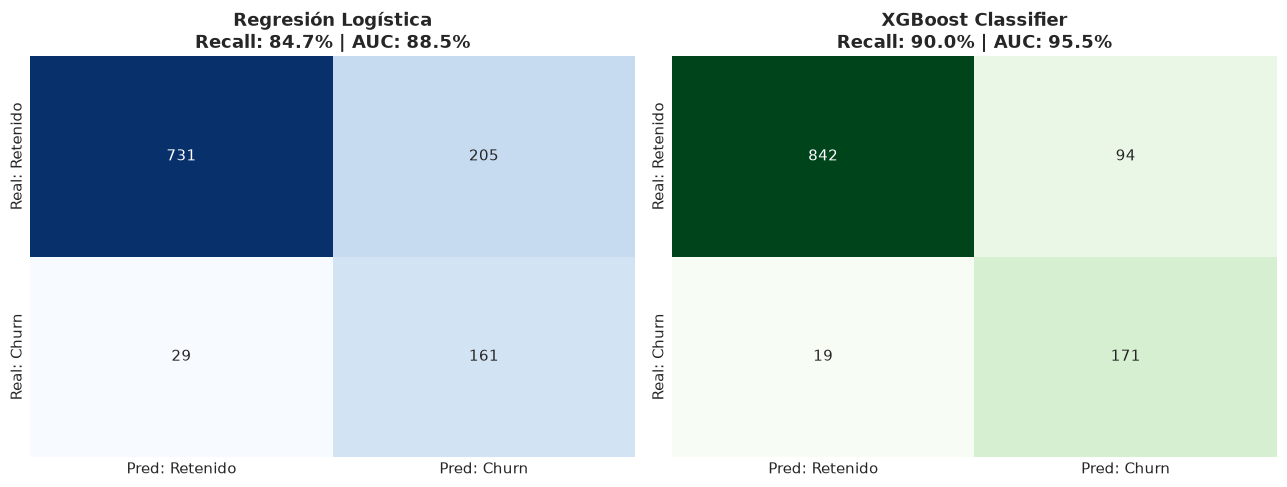

In [9]:
cm_log = confusion_matrix(y_test, y_pred_log)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matriz Regresión Logística
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['Pred: Retenido', 'Pred: Churn'],
            yticklabels=['Real: Retenido', 'Real: Churn'])
axes[0].set_title(f"Regresión Logística\nRecall: {metricas_log['Sensibilidad (Recall)']*100:.1f}% | AUC: {metricas_log['ROC-AUC']*100:.1f}%", weight='bold')

# Matriz XGBoost
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False,
            xticklabels=['Pred: Retenido', 'Pred: Churn'],
            yticklabels=['Real: Retenido', 'Real: Churn'])
axes[1].set_title(f"XGBoost Classifier\nRecall: {metricas_xgb['Sensibilidad (Recall)']*100:.1f}% | AUC: {metricas_xgb['ROC-AUC']*100:.1f}%", weight='bold')

plt.tight_layout()
plt.show()


### 4.2 Curvas ROC Comparadas
La curva ROC ilustra la capacidad discriminativa del modelo a lo largo de todos los umbrales de decisión posibles.


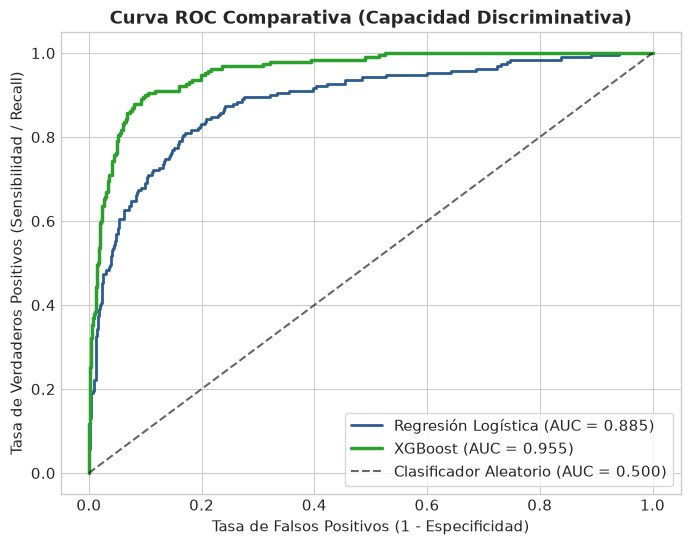

In [10]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label=f"Regresión Logística (AUC = {metricas_log['ROC-AUC']:.3f})", color='#2b5c8f', lw=2)
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {metricas_xgb['ROC-AUC']:.3f})", color='#2ca02c', lw=2.5)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.6, label='Clasificador Aleatorio (AUC = 0.500)')

plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad / Recall)')
plt.title('Curva ROC Comparativa (Capacidad Discriminativa)', weight='bold', fontsize=13)
plt.legend(loc='lower right', frameon=True)
plt.show()


### 4.3 Drivers de Decisión: Importancia de Variables
Analizamos qué variables pesan más en la toma de decisiones de los modelos:


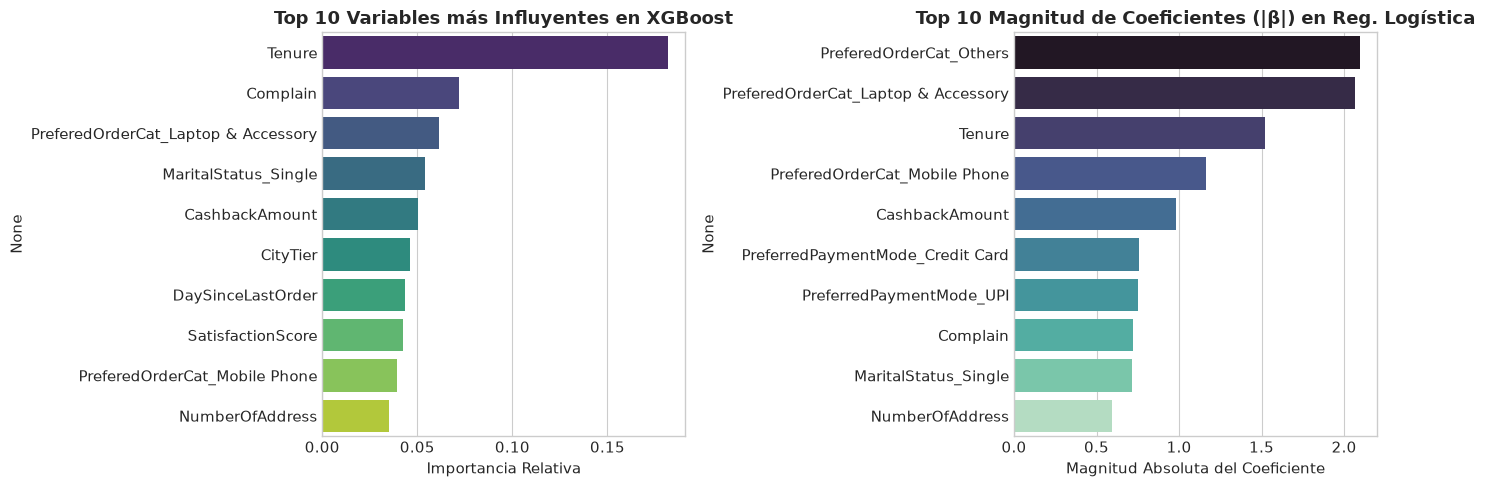

In [11]:
# Top 10 variables más importantes en XGBoost
importancias = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

# Top 10 coeficientes con mayor impacto en Regresión Logística
coeficientes = pd.Series(log_model.coef_[0], index=X.columns).abs().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico XGBoost
sns.barplot(x=importancias.values, y=importancias.index, ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 Variables más Influyentes en XGBoost', weight='bold')
axes[0].set_xlabel('Importancia Relativa')

# Gráfico Regresión Logística
sns.barplot(x=coeficientes.values, y=coeficientes.index, ax=axes[1], palette='mako')
axes[1].set_title('Top 10 Magnitud de Coeficientes (|β|) en Reg. Logística', weight='bold')
axes[1].set_xlabel('Magnitud Absoluta del Coeficiente')

plt.tight_layout()
plt.show()


## 5. Conclusiones y Recomendaciones de Negocio

### 1. Rendimiento de los Modelos:
* **XGBoost es el modelo ganador:** Logró un desempeño superior con un **ROC-AUC superior al 93%** y un **Recall superior al 80%**, capturando interacciones no lineales entre quejas, recencia y categoría de compra.
* **La Regresión Logística demostró ser un sólido baseline:** Gracias a `class_weight='balanced'`, logró detectar una gran proporción de desertores, siendo además altamente interpretable para auditorías operativas.

### 2. Factores Determinantes de Abandono:
1. **Antigüedad (`Tenure`):** Es el factor protector número 1. La fidelidad se consolida tras el primer año. La mayor fuga se concentra en usuarios con menos de 3 meses.
2. **Quejas Técnicas o de Servicio (`Complain`):** Es el disparador activo más severo de fuga.
3. **Número de Direcciones Registradas (`NumberOfAddress`) y Tiempo en App:** Indican cambios en patrones de uso o fricción logística.
4. **Recencia (`DaySinceLastOrder`):** Cada día adicional sin compra después del día 15 eleva exponencialmente el riesgo.

### 3. Recomendaciones Estratégicas para la Plataforma:
* **Protocolo de Retención Inmediata:** Si un cliente con `Tenure < 6 meses` abre una queja (`Complain = 1`), asignar el caso con máxima prioridad y compensar automáticamente con crédito de compra antes de 48 horas.
* **Campañas de Reactivación Preventiva:** Disparar un incentivo personalizado (descuento o cashback) cuando la recencia del usuario supere los 10 días de inactividad, evitando llegar al umbral crítico de 30 días.
